In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Florida Everglades Burmese Python Analysis

## Data Loading

In [10]:
record_data = pd.read_csv('FL_Specimen_Management_Database_Pre-2022PYMO.csv')
record_data.head()

,OID,Year,Date,ID,UTMEast,UTMNorth,Sex,Weight,SVL,TailLength,TotalLength,TailStatus,ReproStatus,#FolliclesOrEggs
0,2,2004.0,2004-10-12,12Oct04.01,530923.0,2806709.0,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,2006.0,2006-09-13,13Sep06.01,519027.0,2807146.0,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8,2007.0,2007-03-24,24Mar07.01,517307.0,2849303.0,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12,2008.0,2008-11-08,08Nov08.01,521952.0,2813389.0,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13,2008.0,2008-11-11,11Nov08.01,541942.0,2808671.0,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print(record_data.shape)
print()
print(record_data[['Sex', 'SVL', 'Weight', 'TotalLength']].isnull().sum())

(7471, 14)

Sex             937
SVL            3354
Weight         2996
TotalLength    4483
dtype: int64


## Descriptive Statistics

In [12]:
print(record_data.describe())

                OID         Year        UTMEast      UTMNorth        Weight  \
count   7471.000000  7442.000000    4101.000000  4.101000e+03   4475.000000   
mean   12823.320305  2016.567186  514356.348939  2.832190e+06   5477.968045   
std     7099.582091     4.327863   28501.872882  2.915619e+04   8845.175500   
min        2.000000  1995.000000  413999.000000  2.726898e+06     40.000000   
25%     6855.500000  2015.000000  494974.000000  2.807146e+06    176.000000   
50%    14051.000000  2018.000000  518927.000000  2.834960e+06   3360.000000   
75%    17521.500000  2020.000000  539948.000000  2.859678e+06   6620.000000   
max    24277.000000  2021.000000  586419.000000  2.915803e+06  84800.000000   

               SVL   TailLength  TotalLength  #FolliclesOrEggs  
count  4117.000000  3024.000000  2988.000000         150.00000  
mean    157.803959    20.141204   161.672289          37.42000  
std      85.785220    11.346362    92.876987          23.57916  
min      39.600000     1.500

In [13]:
print(record_data['Sex'].value_counts())

Sex
Male      3616
Female    2918
Name: count, dtype: int64


The dataset contains 7,471 records from 1995 to 2021. 

Total length averages around 162 cm but ranges all the way up to 557 cm, 
which shows a pretty large size variation. 

Males slightly outnumber females with 3,616 male and 2,918 female records.

Not every python was measured, total length was missing for 4,483 records, 
so analysis using length will be based on the 2,988 records that have it.

## Visualizations

### Figure 1 - Distribution of Total Length

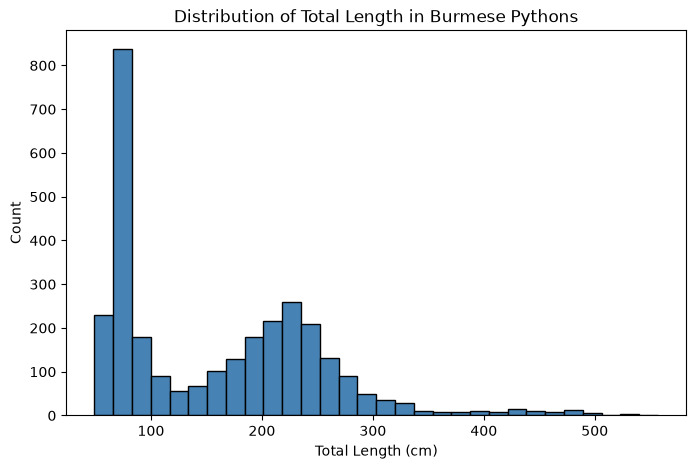

In [14]:
length_records = record_data.dropna(subset=['TotalLength'])

plt.figure(figsize=(8, 5))
plt.hist(length_records['TotalLength'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Total Length in Burmese Pythons')
plt.xlabel('Total Length (cm)')
plt.ylabel('Count')
plt.show()

The distribution of total length shows two clusters. 

A large group of smaller pythons under 100 cm, probably juveniles, and a second group of 
adults centered around 200 to 250 cm. 

A small number of pythons exceed 400 cm, representing the largest individuals in the dataset.

### Figure 2 - Total Length by Sex

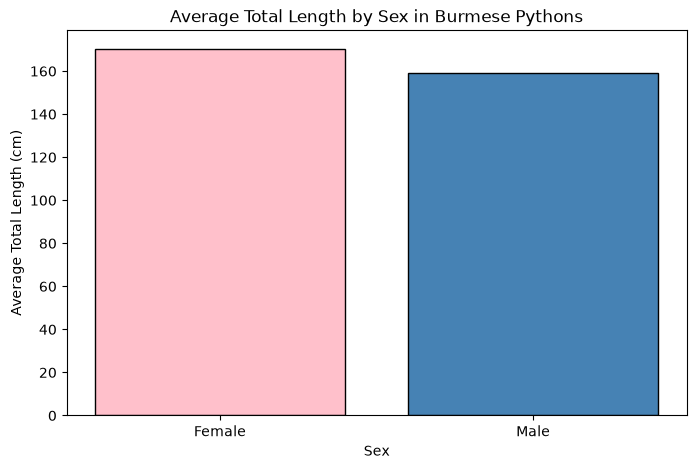

In [19]:
sex_avg = sex_records.groupby('Sex')['TotalLength'].mean()

plt.figure(figsize=(8, 5))
plt.bar(sex_avg.index, sex_avg.values, color=['pink', 'steelblue'], edgecolor='black')
plt.title('Average Total Length by Sex in Burmese Pythons')
plt.xlabel('Sex')
plt.ylabel('Average Total Length (cm)')
plt.show()

Females average slightly longer than males, around 168 cm compared to 160 cm for males. 

While the difference looks small, size variation between sexes is a well documented pattern in large constrictor snakes.

### Figure 3 - Total Length by Year

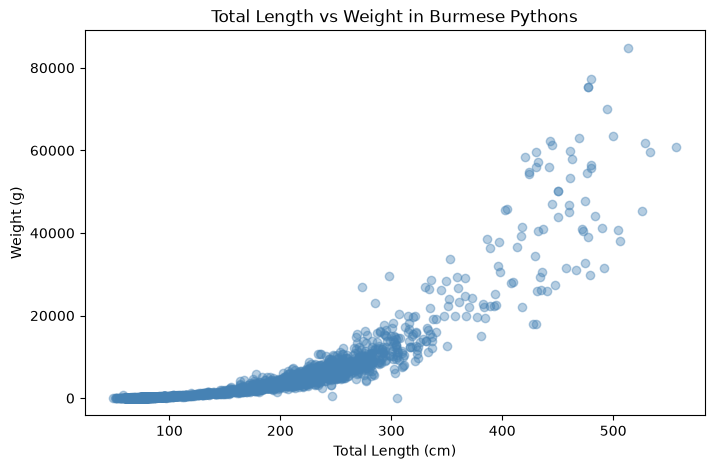

In [21]:
size_records = record_data.dropna(subset=['TotalLength', 'Weight'])

plt.figure(figsize=(8, 5))
plt.scatter(size_records['TotalLength'], size_records['Weight'], 
            color='steelblue', alpha=0.4)
plt.title('Total Length vs Weight in Burmese Pythons')
plt.xlabel('Total Length (cm)')
plt.ylabel('Weight (g)')
plt.show()

Total length and weight show a clear positive relationship, as pythons grow longer they gain weight at an increasing rate. 

The large cluster near zero on the weight axis reflects the high number of juvenile pythons in the dataset, which are significantly smaller than adults.

### Comparing the Three Visualizations

The histogram shows overall size distribution across the full dataset. 

The bar chart isolates the difference between sexes. 

The scatterplot shows how two numeric variables relate to each other. 

Together they give a more complete picture than any one chart could on its own.

## Hypothesis Test

**Null Hypothesis:** There is no significant difference in total length between male and female Burmese pythons.

**Alternative Hypothesis:** There is a significant difference in total length between male and female Burmese pythons.

In [22]:
male_length = sex_records[sex_records['Sex'] == 'Male']['TotalLength']
female_length = sex_records[sex_records['Sex'] == 'Female']['TotalLength']

result = stats.ttest_ind(male_length, female_length)

print('T-statistic:', result.statistic)
print('P-value:', result.pvalue)

T-statistic: -3.241349849268623
P-value: 0.0012032317850662615


The p-value of 0.0012 is well below the standard significance threshold of 0.05, so we reject the null hypothesis. 

There is a significant difference in total length between male and female Burmese pythons, with females averaging longer than males.

## Summary

This analysis looked at total length measurements from 2,988 Burmese python records out of 7,471 total, collected in South Florida between 1995 and 2021.

The data showed a wide range of sizes, from small juveniles under 100 cm to adults exceeding 500 cm. 

A t-test confirmed that female pythons are significantly longer than males on average. 

One unexpected thing was how many records were missing measurements, nearly 4,500 out of 7,471 had no total length recorded, which made the sample for length analysis smaller than expected. 

Getting the dataset loaded and figuring out which columns had enough data to actually work with took some time at the start.